# 02 — Peer Group Scoring Experiment

Peer groups, percentile scores, and worked examples (low / medium / high).

In [1]:
import notebook_lib as nb
import pandas as pd

nb.setup_path()
df = nb.load_and_score()
print(f"Scored {len(df)} submissions | mean {df['final_score'].mean():.2f}")
print(df['risk_band'].value_counts())

Scored 500 submissions | mean 38.87
risk_band
Medium    436
High       48
Low        16
Name: count, dtype: int64


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\02_score_distribution.png


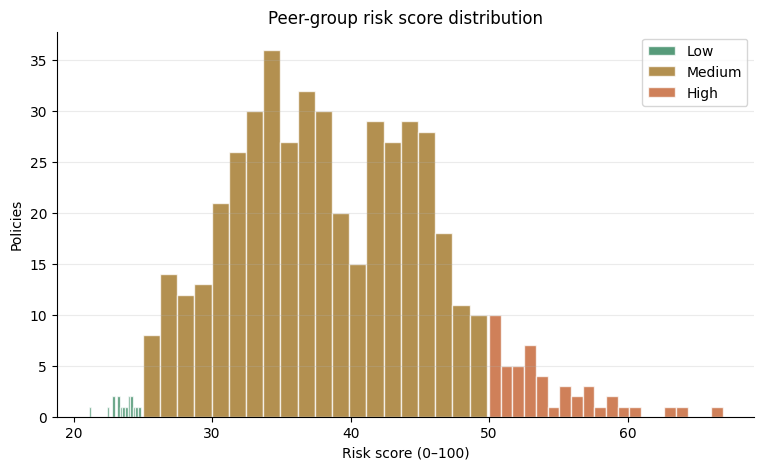

Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\02_risk_bands.png


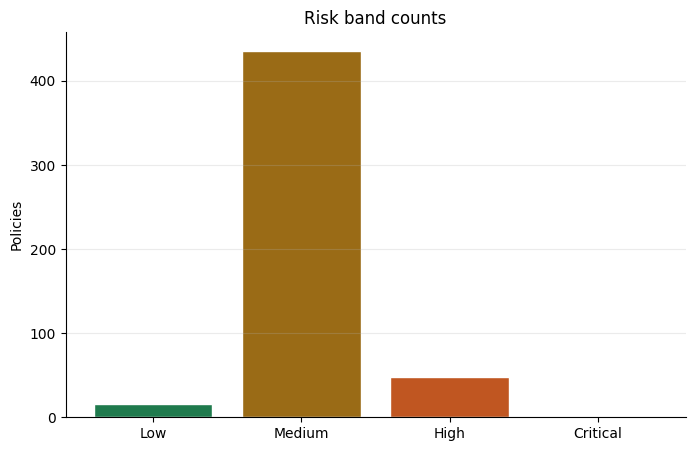

WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/02_risk_bands.png')

In [2]:
nb.plot_score_distribution(df)
nb.plot_risk_bands(df)

In [3]:
display(df['peer_group'].value_counts().head(10))
median = df['final_score'].median()
examples = [
    ('Low', df.nsmallest(1, 'final_score').iloc[0]),
    ('Medium', df.iloc[(df['final_score'] - median).abs().argsort()[:1]].iloc[0]),
    ('High', df.nlargest(1, 'final_score').iloc[0]),
]
for label, row in examples:
    print('=' * 60)
    print(label, '|', row['policy_no'], '|', row['final_score'], '|', row['risk_band'])
    print('Peer:', row['peer_group'])
    for item in nb.build_explanations(df, row['submission_id'])[:5]:
        p = item['peer_percentile']
        print(f"  {item['variable']}: peer {p:.0f}th" if p is not None else f"  {item['variable']}: n/a")

peer_group
CA / Non-Admitted / HO / Primary    77
FL / Non-Admitted / HO / Primary    36
NY / Non-Admitted / HO / Primary    32
CT / Admitted / HO / Primary        29
NJ / Admitted / HO / Primary        29
PA / Admitted / HO / Primary        26
FL / Admitted / HO / Primary        22
TX / Non-Admitted / HO / Primary    21
IL / Admitted / HO / Primary        21
TX / Admitted / HO / Primary        15
Name: count, dtype: int64

Low | HO200089145 | 21.09 | Low
Peer: MA / Admitted / HO / Primary
  contents_limit_amt: peer 72th
  prior_water_claim_ct: peer 88th
  total_finished_square_feet: peer 61th
  roof_age_years: peer 72th
  prior_nonwater_claim_ct: peer 62th
Medium | HO100007494-05 | 37.84 | Medium
Peer: CT / Admitted / HO / Primary
  total_finished_square_feet: peer 66th
  lifetime_loss_incurred_amt: peer 80th
  Distance to Coast: peer 59th
  Lifetime Claim Count: peer 61th
  roof_age_years: peer 61th
High | HO100022152-05 | 66.86 | High
Peer: GA / Admitted / HO / Primary
  contents_limit_amt: peer 100th
  Dwelling Limit: peer 100th
  total_finished_square_feet: peer 100th
  Total Insured Value: peer 100th
  Lifetime Claim Count: peer 100th


Saved: C:\Users\FEDERICO\OneDrive\Escritorio\Vault\DEMOs\metal-peer-risk-scoring\notebooks\reports\figures\02_peer_tiv_example.png


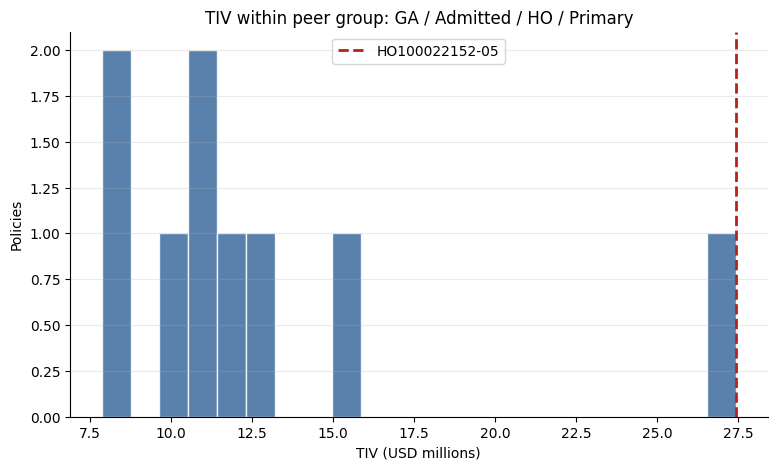

WindowsPath('C:/Users/FEDERICO/OneDrive/Escritorio/Vault/DEMOs/metal-peer-risk-scoring/notebooks/reports/figures/02_peer_tiv_example.png')

In [4]:
high_row = examples[-1][1]
nb.plot_peer_tiv(df, high_row)

Full ML comparison is in **notebook 04**.